In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

In [3]:
courses = pd.read_csv('EduPro Online Platform.xlsx - Courses.csv')
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [4]:
users = pd.read_csv('EduPro Online Platform.xlsx - Users.csv')
users.head()

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [5]:
transactions = pd.read_csv('EduPro Online Platform.xlsx - Transactions.csv')
transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042


In [6]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


In [7]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     object 
 1   CourseName      60 non-null     object 
 2   CourseCategory  60 non-null     object 
 3   CourseType      60 non-null     object 
 4   CourseLevel     60 non-null     object 
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.9+ KB


In [8]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    10000 non-null  object 
 1   UserID           10000 non-null  object 
 2   CourseID         10000 non-null  object 
 3   TransactionDate  10000 non-null  object 
 4   Amount           10000 non-null  float64
 5   PaymentMethod    10000 non-null  object 
 6   TeacherID        10000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.0+ KB


In [9]:
users.describe()

,Age
count,3000.000000
mean,24.974333
std,6.046475
min,15.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,35.000000


In [10]:
courses.describe()

,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000


In [11]:
transactions.describe()

,Amount
count,10000.000000
mean,91.132347
std,152.063524
min,0.000000
25%,0.000000
50%,0.000000
75%,119.040000
max,490.900000


In [12]:
df = transactions.merge(users, on = 'UserID')
df = df.merge(courses, on = 'CourseID')
df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age,Gender,Email,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040,fthornton,23,Female,christensencatherine@outlook.com,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042,fthornton,23,Female,christensencatherine@outlook.com,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


In [13]:
df.to_csv("original_dataset.csv", index = False)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    10000 non-null  object 
 1   UserID           10000 non-null  object 
 2   CourseID         10000 non-null  object 
 3   TransactionDate  10000 non-null  object 
 4   Amount           10000 non-null  float64
 5   PaymentMethod    10000 non-null  object 
 6   TeacherID        10000 non-null  object 
 7   UserName         10000 non-null  object 
 8   Age              10000 non-null  int64  
 9   Gender           10000 non-null  object 
 10  Email            10000 non-null  object 
 11  CourseName       10000 non-null  object 
 12  CourseCategory   10000 non-null  object 
 13  CourseType       10000 non-null  object 
 14  CourseLevel      10000 non-null  object 
 15  CoursePrice      10000 non-null  float64
 16  CourseDuration   10000 non-null  float64
 17  CourseRating 

In [15]:
df.isnull().sum()

,0
TransactionID,0
UserID,0
CourseID,0
TransactionDate,0
Amount,0
PaymentMethod,0
TeacherID,0
UserName,0
Age,0
Gender,0


In [16]:
df.describe()

,Amount,Age,CoursePrice,CourseDuration,CourseRating
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,91.132347,24.965700,91.132347,27.509536,3.123277
std,152.063524,6.051858,152.063524,16.011616,1.156254
min,0.000000,15.000000,0.000000,1.200000,1.130000
25%,0.000000,20.000000,0.000000,12.130000,2.140000
50%,0.000000,25.000000,0.000000,28.330000,3.110000
75%,119.040000,30.000000,119.040000,42.700000,4.110000
max,490.900000,35.000000,490.900000,49.730000,4.940000


In [17]:
df.drop(columns='CoursePrice', inplace=True)

In [18]:
print(df['CourseCategory'].value_counts())

CourseCategory
Data Science               916
Finance                    864
Web Development            844
Business                   833
Artificial Intelligence    829
Project Management         829
Design                     827
Cybersecurity              819
Machine Learning           819
Digital Marketing          808
Marketing                  806
Programming                806
Name: count, dtype: int64


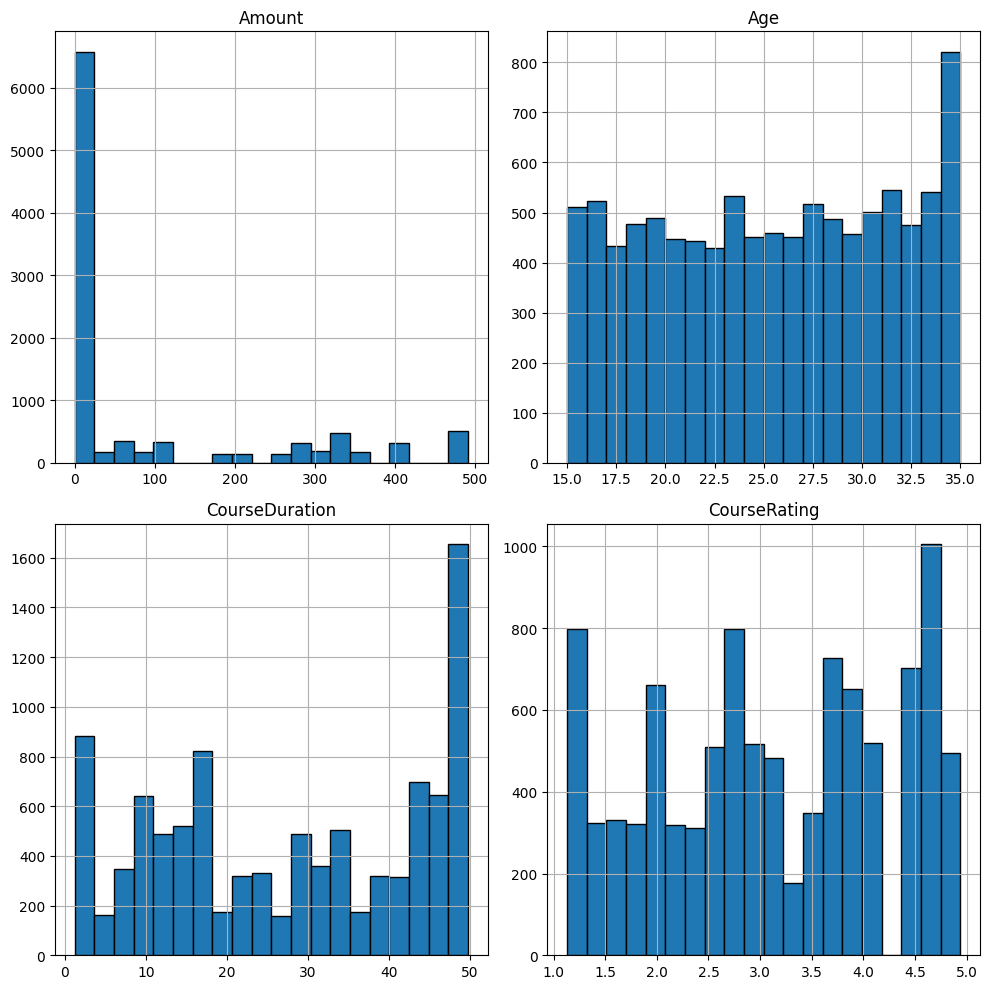

In [19]:
df.hist(figsize=(10,10), bins = 20, edgecolor='black')
plt.tight_layout()
plt.show()

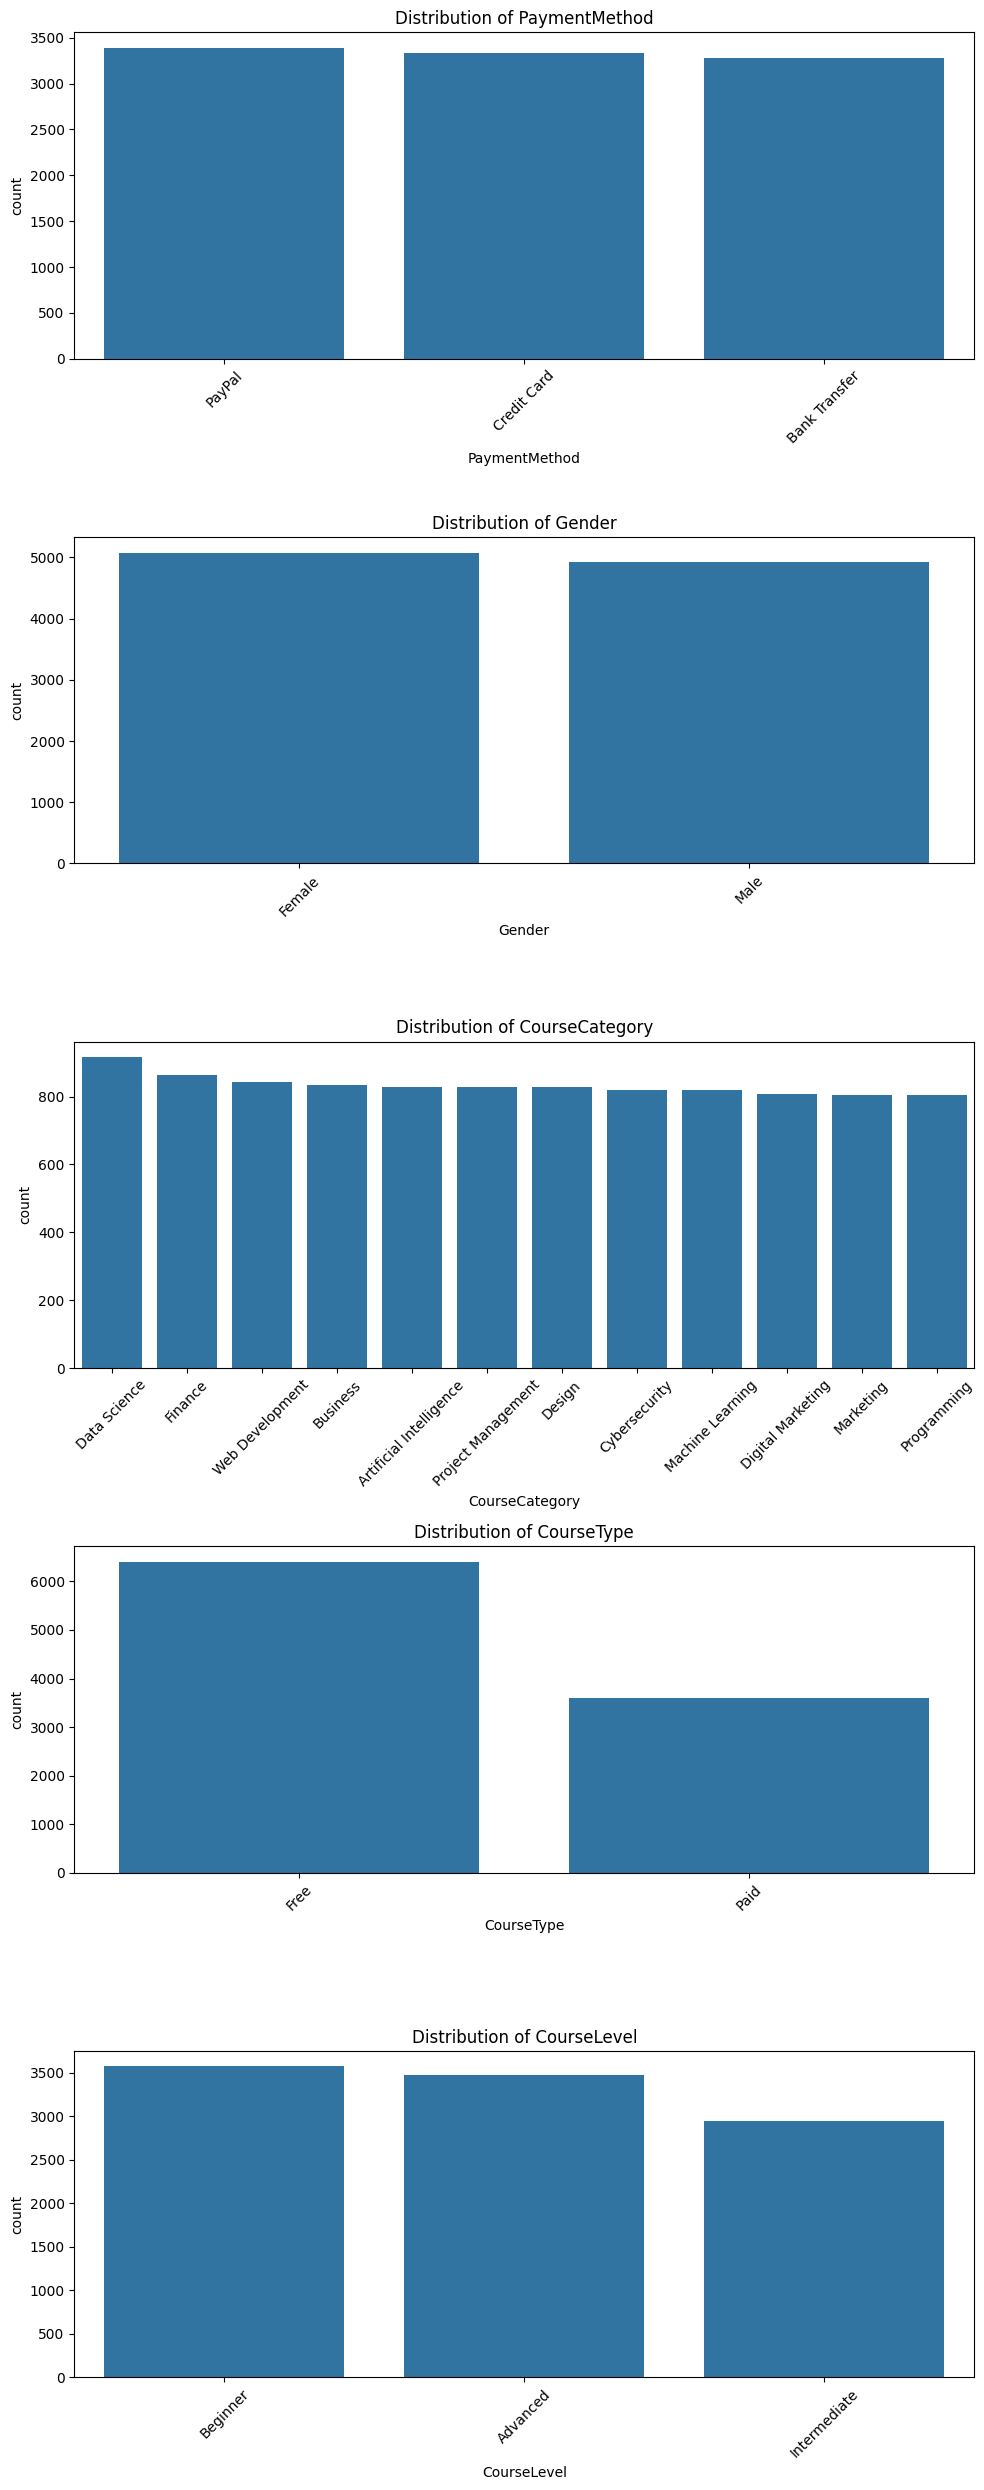

In [20]:
# Identify categorical columns suitable for bar plots
categorical_for_bars = ['PaymentMethod', 'Gender', 'CourseCategory', 'CourseType', 'CourseLevel']

# Create subplots dynamically
num_features = len(categorical_for_bars)
fig, axes = plt.subplots(nrows=num_features, ncols=1, figsize=(10, 5 * num_features))

# Ensure 'axes' is always an iterable array, even for a single subplot
if num_features == 1:
    axes = [axes]

# Loop through each selected categorical column and create a bar plot
for i, col in enumerate(categorical_for_bars):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

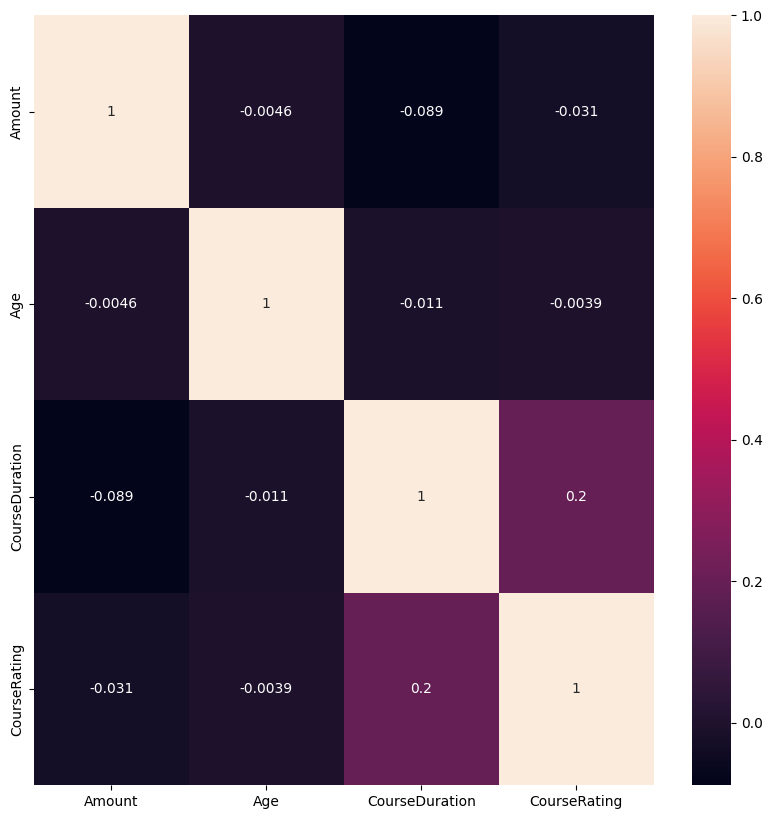

In [21]:
cor = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(cor, annot=True)
plt.show()

In [22]:
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'Age', 'Gender', 'Email',
       'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CourseDuration', 'CourseRating'],
      dtype='object')

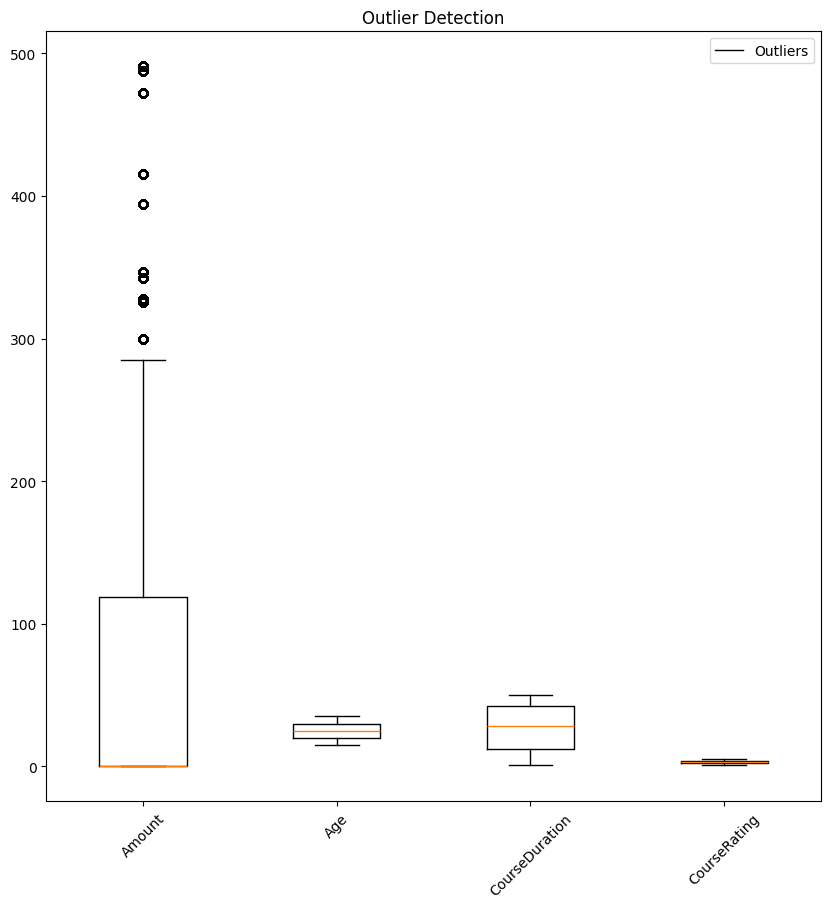

In [23]:
col = ['Amount', 'Age', 'CourseDuration', 'CourseRating']
plt.figure(figsize=(10, 10))
plt.boxplot([df[i] for i in col], tick_labels=col)
plt.title('Outlier Detection')
plt.xticks(rotation=45)
plt.legend(['Outliers'])
plt.show()

In [24]:
col = ['Amount']
for i in col:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df = df[(df[i] < lower_bound) | (df[i] > upper_bound)]

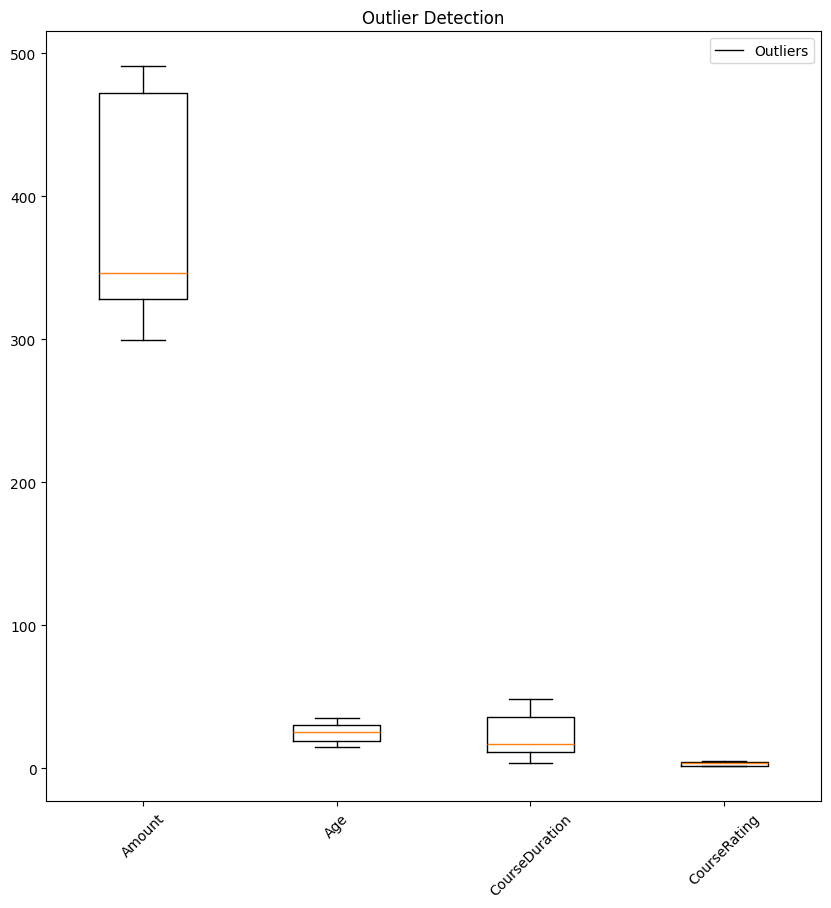

In [25]:
col = ['Amount', 'Age', 'CourseDuration', 'CourseRating']
plt.figure(figsize=(10, 10))
plt.boxplot([df[i] for i in col], tick_labels=col)
plt.title('Outlier Detection')
plt.xticks(rotation=45)
plt.legend(['Outliers'])
plt.show()

In [26]:
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'Age', 'Gender', 'Email',
       'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CourseDuration', 'CourseRating'],
      dtype='object')

In [27]:
#drop_cols = ['TransactionID', 'UserID', 'CourseID', 'TeacherID', 'UserName', 'Email']
#df = df.drop(columns = drop_cols)

In [28]:
df['Total_courses_enrolled'] = df.groupby('UserID')['CourseID'].transform('count')

In [29]:
category_count = df.groupby(['UserID', 'CourseCategory'])['CourseID'].count().reset_index(name='count')
avg_category = category_count.groupby('UserID')['count'].mean().reset_index(name='AvgCoursesPerCategory')
df = df.merge(avg_category, on='UserID', how='left')

In [30]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True)
days = df.groupby('UserID')['TransactionDate'].agg(['min', 'max'])
days['Enrollment_frequency'] = (df.groupby('UserID').size() / ((days['max'] - days['min']).dt.days + 1))
df = df.merge(days['Enrollment_frequency'], on = 'UserID', how = 'left')

In [31]:
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month
df["Day"] = df["TransactionDate"].dt.day
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

In [32]:
preferred_category = (
    df.groupby('UserID')['CourseCategory'].agg(lambda x: x.mode()[0])
    .reset_index(name='PreferredCategory')
)
df = df.merge(preferred_category, on='UserID', how='left')

In [33]:
preferred_level = (
    df.groupby('UserID')['CourseLevel'].agg(lambda x: x.mode()[0])
    .reset_index(name = 'PreferredLevel')
)
df = df.merge(preferred_level, on = 'UserID', how = 'left')

In [34]:
df['AvgCourseRating'] = (
    df.groupby('UserID')['CourseRating'].transform('mean')
)

In [35]:
df['AvgSpending'] = (
    df.groupby('UserID')['Amount'].transform('mean')
)

In [36]:
df['DiversityScore'] = (
    df.groupby('UserID')['CourseCategory'].transform('nunique')
)

In [37]:
level_map = {
    'Beginner' : 1,
    'Intermediate' : 2,
    'Advanced' : 3
}
df['LevelScore'] = df['CourseLevel'].map(level_map)
df['Learningdepthlevel'] = (
    df.groupby('UserID')['LevelScore'].transform('mean')
)

In [38]:
df['Age_group'] = pd.cut(df['Age'], bins = [0, 18, 25, 35, 50], labels = ['Teen', 'Young', 'Adult', 'Senior'])

In [39]:
df['HighlyRated'] = (df['CourseRating'] >= 4.5).astype(int)

In [40]:
df['ExcellentCourse'] = (df['CourseRating'] > 4.8).astype(int)

In [41]:
df['LongDurationCourse'] = (df['CourseDuration'] > 40).astype(int)

In [42]:
df['ShortDurationCourse'] = (df['CourseDuration'] < 10).astype(int)

In [43]:
df["TotalSpent"] = df.groupby("UserID")["Amount"].transform("sum")

In [44]:
df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age,Gender,...,AvgSpending,DiversityScore,LevelScore,Learningdepthlevel,Age_group,HighlyRated,ExcellentCourse,LongDurationCourse,ShortDurationCourse,TotalSpent
0,TT00008,U00004,CR00025,2025-05-07,299.57,Credit Card,TC00040,fthornton,23,Female,...,321.090,2,1,1.5,Young,0,0,1,0,642.18
1,TT00016,U00015,CR00040,2025-12-22,327.99,Credit Card,TC00040,tbaker,27,Female,...,388.940,3,1,1.5,Adult,0,0,0,0,1555.76
2,TT00021,U00018,CR00001,2025-03-24,472.28,PayPal,TC00042,nicole97,24,Female,...,400.135,2,1,1.0,Young,1,0,0,0,800.27
3,TT00023,U00028,CR00040,2025-05-06,327.99,Bank Transfer,TC00042,zgomez,30,Female,...,400.135,2,1,1.0,Adult,0,0,0,0,800.27
4,TT00035,U00048,CR00025,2025-05-08,299.57,Credit Card,TC00040,willie71,19,Male,...,299.570,1,1,1.0,Young,0,0,1,0,299.57


In [45]:
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'Age', 'Gender', 'Email',
       'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CourseDuration', 'CourseRating', 'Total_courses_enrolled',
       'AvgCoursesPerCategory', 'Enrollment_frequency', 'Year', 'Month', 'Day',
       'DayOfWeek', 'PreferredCategory', 'PreferredLevel', 'AvgCourseRating',
       'AvgSpending', 'DiversityScore', 'LevelScore', 'Learningdepthlevel',
       'Age_group', 'HighlyRated', 'ExcellentCourse', 'LongDurationCourse',
       'ShortDurationCourse', 'TotalSpent'],
      dtype='object')

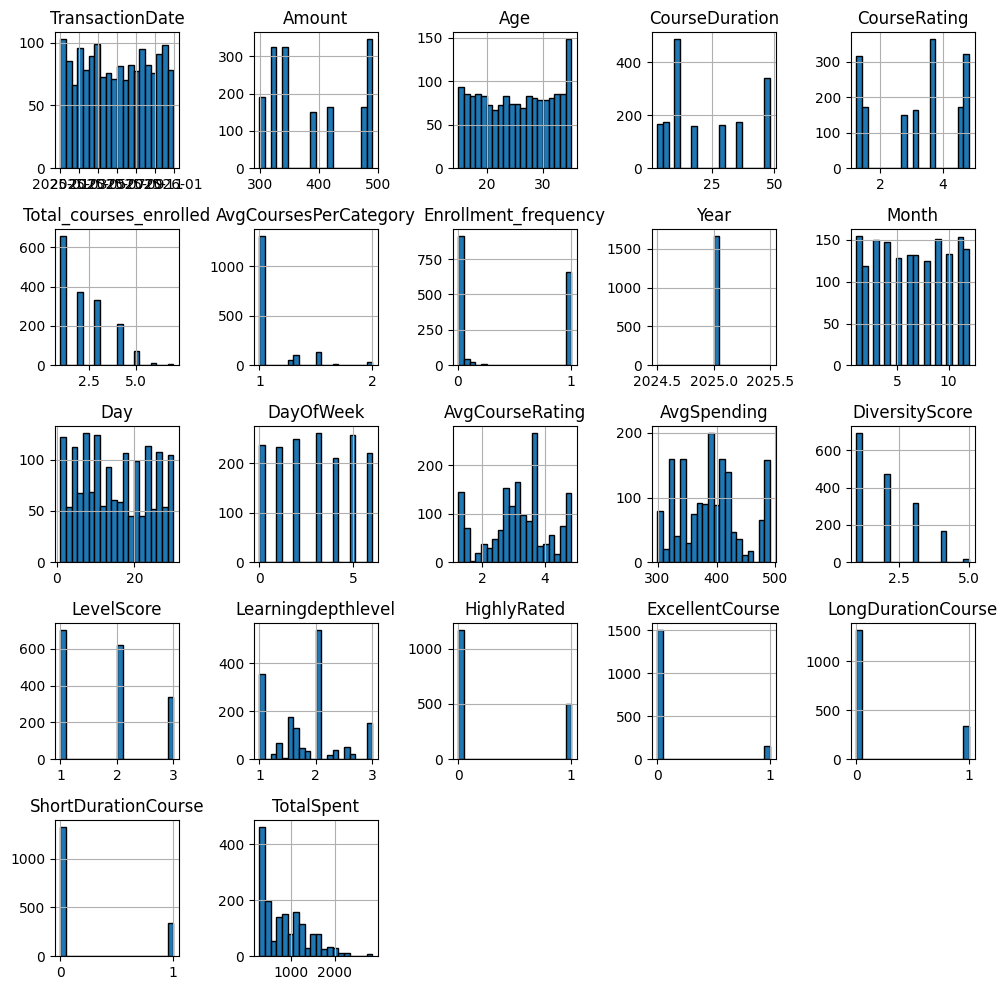

In [46]:
df.hist(figsize=(10,10), bins = 20, edgecolor='black')
plt.tight_layout()
plt.show()

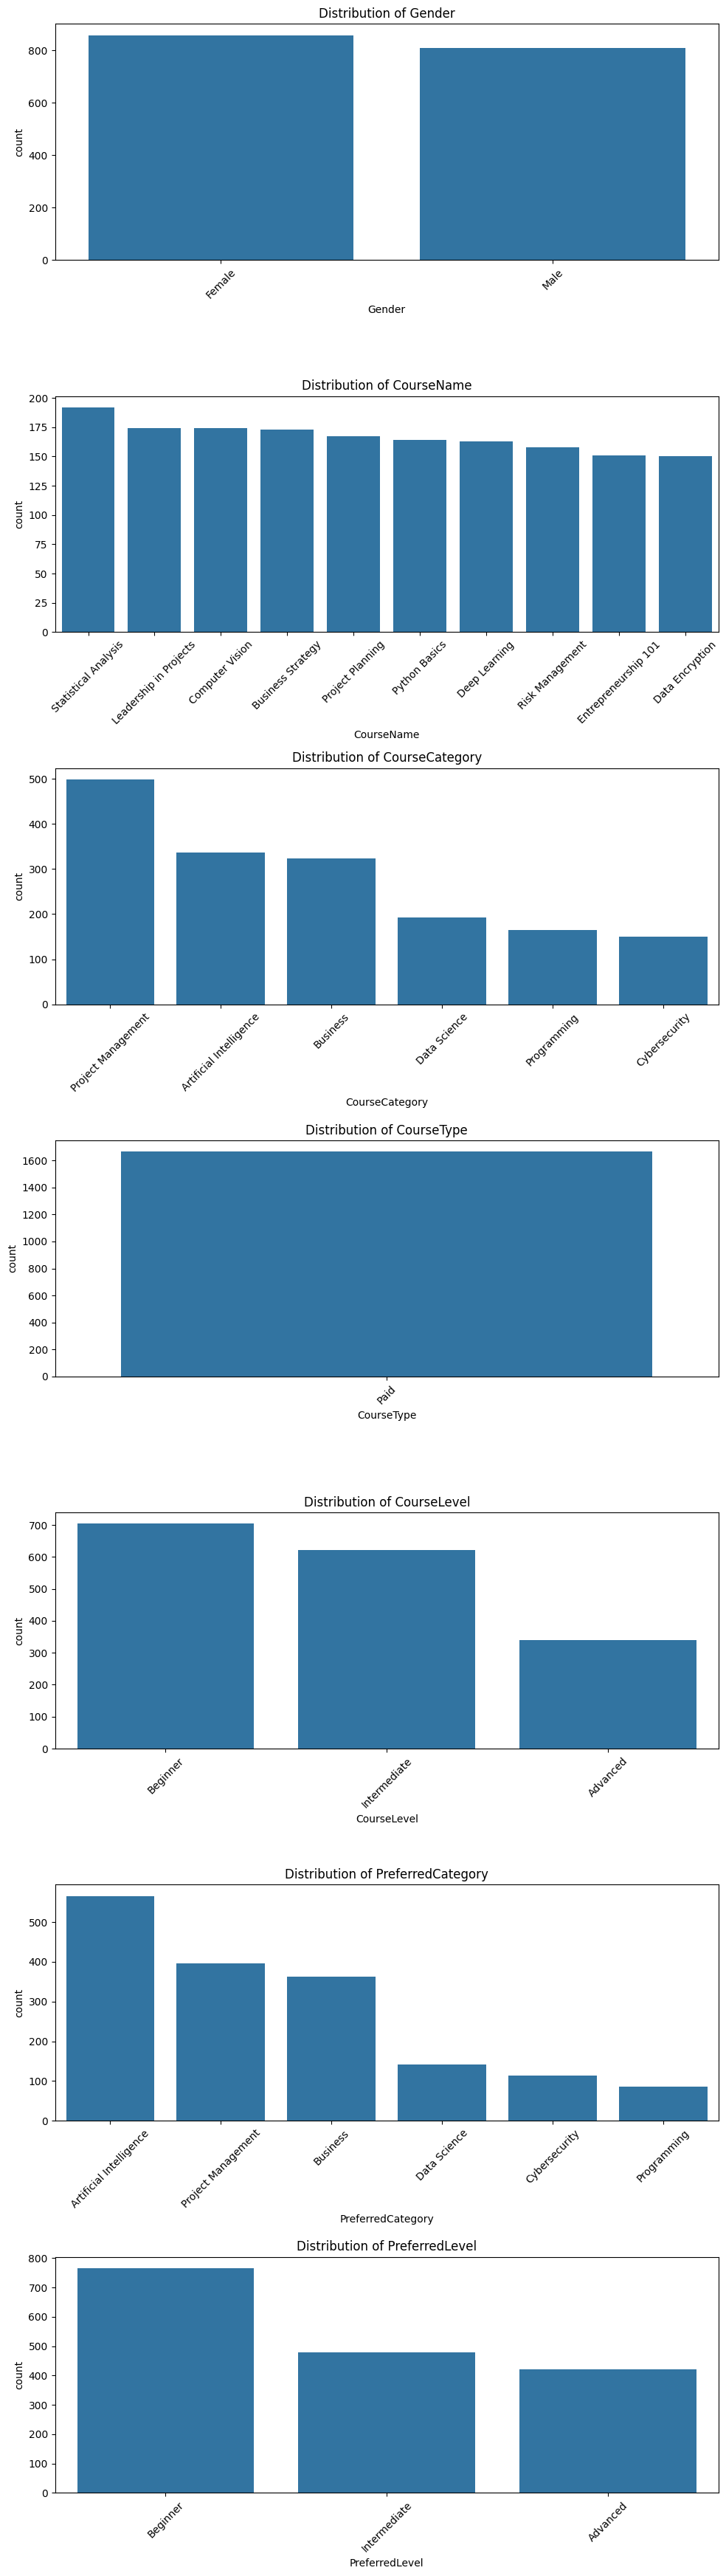

In [47]:
categorical_for_bars_new = ['Gender','CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'PreferredCategory',
 'PreferredLevel']

num_features_new = len(categorical_for_bars_new)
fig, axes = plt.subplots(nrows=num_features_new, ncols=1, figsize=(10, 5 * num_features_new))

if num_features_new == 1:
    axes = [axes]

for i, col in enumerate(categorical_for_bars_new):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [48]:
print(df['CourseCategory'].value_counts())

CourseCategory
Project Management         499
Artificial Intelligence    337
Business                   324
Data Science               192
Programming                164
Cybersecurity              150
Name: count, dtype: int64


In [49]:
df.select_dtypes(include='object').columns.tolist()

['TransactionID',
 'UserID',
 'CourseID',
 'PaymentMethod',
 'TeacherID',
 'UserName',
 'Gender',
 'Email',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'PreferredCategory',
 'PreferredLevel']

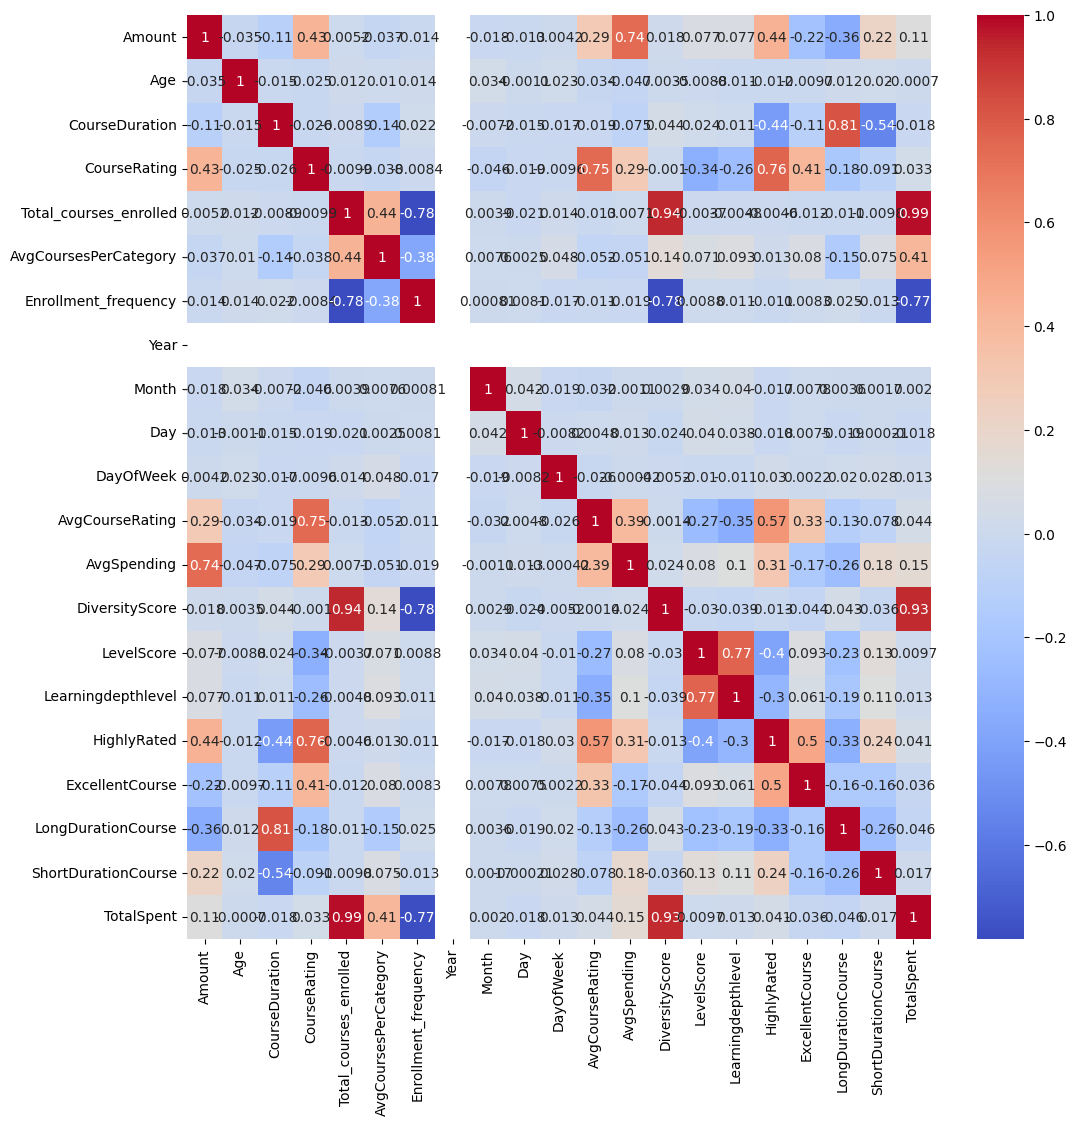

In [50]:
cor = df.corr(numeric_only = True)
plt.figure(figsize=(12, 12))
sns.heatmap(cor, cmap = 'coolwarm', annot = True)
plt.show()

In [51]:
df.isnull().sum()

,0
TransactionID,0
UserID,0
CourseID,0
TransactionDate,0
Amount,0
PaymentMethod,0
TeacherID,0
UserName,0
Age,0
Gender,0


In [52]:
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'Age', 'Gender', 'Email',
       'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CourseDuration', 'CourseRating', 'Total_courses_enrolled',
       'AvgCoursesPerCategory', 'Enrollment_frequency', 'Year', 'Month', 'Day',
       'DayOfWeek', 'PreferredCategory', 'PreferredLevel', 'AvgCourseRating',
       'AvgSpending', 'DiversityScore', 'LevelScore', 'Learningdepthlevel',
       'Age_group', 'HighlyRated', 'ExcellentCourse', 'LongDurationCourse',
       'ShortDurationCourse', 'TotalSpent'],
      dtype='object')

In [53]:
drop_col = ['TransactionDate', 'TransactionID', 'UserID', 'CourseID', 'TeacherID', 'UserName', 'Email']
df = df.drop(columns = drop_col)

In [54]:
df.columns

Index(['Amount', 'PaymentMethod', 'Age', 'Gender', 'CourseName',
       'CourseCategory', 'CourseType', 'CourseLevel', 'CourseDuration',
       'CourseRating', 'Total_courses_enrolled', 'AvgCoursesPerCategory',
       'Enrollment_frequency', 'Year', 'Month', 'Day', 'DayOfWeek',
       'PreferredCategory', 'PreferredLevel', 'AvgCourseRating', 'AvgSpending',
       'DiversityScore', 'LevelScore', 'Learningdepthlevel', 'Age_group',
       'HighlyRated', 'ExcellentCourse', 'LongDurationCourse',
       'ShortDurationCourse', 'TotalSpent'],
      dtype='object')

In [55]:
df.select_dtypes(include='object').columns.tolist()

['PaymentMethod',
 'Gender',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'PreferredCategory',
 'PreferredLevel']

In [56]:
df.columns

Index(['Amount', 'PaymentMethod', 'Age', 'Gender', 'CourseName',
       'CourseCategory', 'CourseType', 'CourseLevel', 'CourseDuration',
       'CourseRating', 'Total_courses_enrolled', 'AvgCoursesPerCategory',
       'Enrollment_frequency', 'Year', 'Month', 'Day', 'DayOfWeek',
       'PreferredCategory', 'PreferredLevel', 'AvgCourseRating', 'AvgSpending',
       'DiversityScore', 'LevelScore', 'Learningdepthlevel', 'Age_group',
       'HighlyRated', 'ExcellentCourse', 'LongDurationCourse',
       'ShortDurationCourse', 'TotalSpent'],
      dtype='object')

In [57]:
df.to_csv("learner_dataset.csv", index = False)

In [58]:
ob_col = ['PaymentMethod',
 'Gender',
  'Age_group',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'PreferredCategory',
 'PreferredLevel']


In [59]:
df1 = pd.get_dummies(df, columns = ob_col, drop_first = True)

In [60]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 50 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Amount                                1666 non-null   float64
 1   Age                                   1666 non-null   int64  
 2   CourseDuration                        1666 non-null   float64
 3   CourseRating                          1666 non-null   float64
 4   Total_courses_enrolled                1666 non-null   int64  
 5   AvgCoursesPerCategory                 1666 non-null   float64
 6   Enrollment_frequency                  1666 non-null   float64
 7   Year                                  1666 non-null   int32  
 8   Month                                 1666 non-null   int32  
 9   Day                                   1666 non-null   int32  
 10  DayOfWeek                             1666 non-null   int32  
 11  AvgCourseRating  

In [61]:
numerical_cols = df1.select_dtypes(include = ['int64', 'float64']).columns
scaler = StandardScaler()
df1[numerical_cols] = scaler.fit_transform(df1[numerical_cols])

In [62]:
import pickle

scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

print(f"StandardScaler saved to {scaler_filename}")

StandardScaler saved to scaler.pkl


In [63]:
df1.head()

,Amount,Age,CourseDuration,CourseRating,Total_courses_enrolled,AvgCoursesPerCategory,Enrollment_frequency,Year,Month,Day,...,CourseCategory_Project Management,CourseLevel_Beginner,CourseLevel_Intermediate,PreferredCategory_Business,PreferredCategory_Cybersecurity,PreferredCategory_Data Science,PreferredCategory_Programming,PreferredCategory_Project Management,PreferredLevel_Beginner,PreferredLevel_Intermediate
0,-1.293198,-0.307743,1.623501,0.437973,-0.185240,-0.465922,-0.833892,2025,5,7,...,False,True,False,False,False,True,False,False,True,False
1,-0.887470,0.342272,-0.650527,-1.247335,1.365560,1.073446,-0.618436,2025,12,22,...,True,True,False,False,False,False,False,True,True,False
2,1.172434,-0.145239,-0.721531,1.193716,-0.185240,-0.465922,-0.857313,2025,3,24,...,False,True,False,False,False,False,True,False,True,False
3,-0.887470,0.829784,-0.650527,-1.247335,-0.185240,-0.465922,-0.759575,2025,5,6,...,True,True,False,False,False,False,True,False,True,False
4,-1.293198,-0.957758,1.623501,0.437973,-0.960639,-0.465922,1.228416,2025,5,8,...,False,True,False,False,False,True,False,False,True,False


In [64]:
df1.to_csv("final_dataset.csv", index = False)

In [65]:
inertia = []
for k in range(1, 11):
  model = KMeans(
      n_clusters = k,
      random_state = 42
      )
  model.fit(df1)
  inertia.append(model.inertia_)

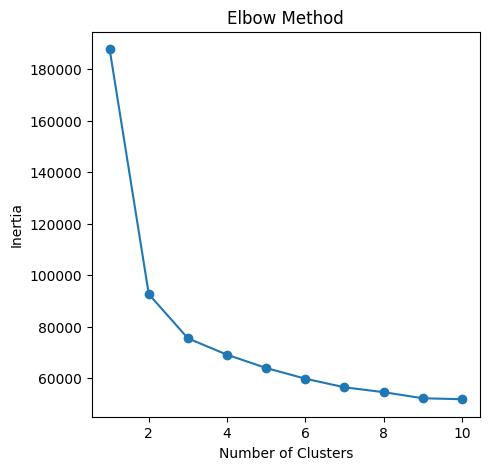

In [66]:
plt.figure(figsize=(5, 5))
plt.plot(range(1, 11), inertia, marker = 'o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [67]:
scores = []
for k in range(2, 11):
  model = KMeans(
      n_clusters = k,
      random_state = 42
  )
  labels = model.fit_predict(df1)
  score = silhouette_score(
      df1,
      labels
      )
  scores.append(score)
  print("Clusters:", k,
          "Score:", score)

Clusters: 2 Score: 0.39536457206809006
Clusters: 3 Score: 0.2564548621998088
Clusters: 4 Score: 0.2066663927909669
Clusters: 5 Score: 0.1728924031124736
Clusters: 6 Score: 0.16315293974172831
Clusters: 7 Score: 0.15713120740802564
Clusters: 8 Score: 0.1431259733806328
Clusters: 9 Score: 0.13800236801160604
Clusters: 10 Score: 0.11820546089913776


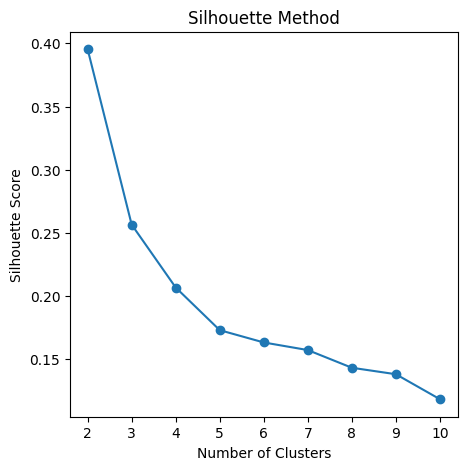

In [68]:
plt.figure(figsize = (5, 5))
plt.plot(range(2, 11), scores, marker = 'o')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [69]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

df1_pca = pca.fit_transform(df1)

In [70]:
import pickle

pca_filename = 'pca.pkl'
with open(pca_filename, 'wb') as file:
    pickle.dump(pca, file)

print(f"PCA model saved to {pca_filename}")

PCA model saved to pca.pkl


In [71]:
model = KMeans(
    n_clusters=2,
    random_state=42
)
df['clusters'] = model.fit_predict(df1_pca)

In [72]:
learner_df = pd.read_csv('learner_dataset.csv')
learner_df["Cluster"] = model.labels_
learner_df.to_csv("learner_dataset.csv", index=False)

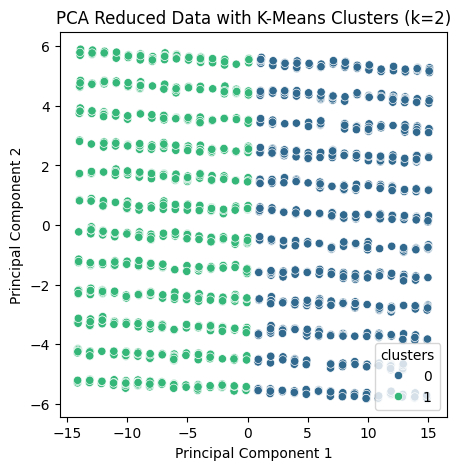

In [73]:
plt.figure(figsize=(5, 5))
sns.scatterplot(
    x=df1_pca[:, 0],
    y=df1_pca[:, 1],
    hue=df['clusters'],
    palette='viridis',
    legend='full'
)
plt.title('PCA Reduced Data with K-Means Clusters (k=2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [74]:
df1['clusters'] = df['clusters']
cluster_summary = df1.groupby('clusters').mean()
print('Cluster Summary (Mean values of features per cluster):')
display(cluster_summary)

Cluster Summary (Mean values of features per cluster):


,Amount,Age,CourseDuration,CourseRating,Total_courses_enrolled,AvgCoursesPerCategory,Enrollment_frequency,Year,Month,Day,...,CourseCategory_Project Management,CourseLevel_Beginner,CourseLevel_Intermediate,PreferredCategory_Business,PreferredCategory_Cybersecurity,PreferredCategory_Data Science,PreferredCategory_Programming,PreferredCategory_Project Management,PreferredLevel_Beginner,PreferredLevel_Intermediate
clusters,,,,,,,,,,,,,,,,,,,,,
0,-0.042157,-0.004292,-0.023645,-0.044864,-0.038863,-0.002835,0.028081,2025.0,6.676020,23.011480,...,0.320153,0.395408,0.386480,0.225765,0.066327,0.080357,0.056122,0.247449,0.443878,0.297194
1,0.037473,0.003815,0.021018,0.039879,0.034545,0.002520,-0.024961,2025.0,6.351474,7.879819,...,0.281179,0.446712,0.361678,0.210884,0.069161,0.089569,0.047619,0.229025,0.473923,0.280045


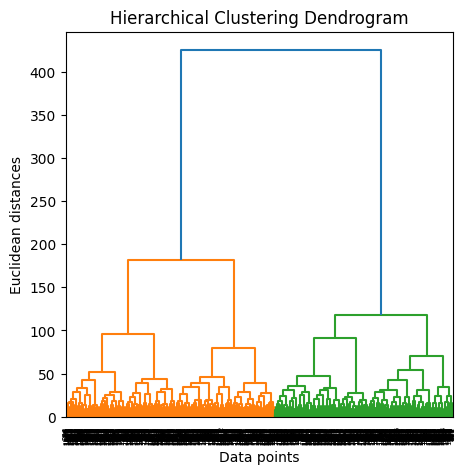

In [75]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(df1, method='ward')

plt.figure(figsize=(5, 5))
dendrogram(linked,
            orientation='top',
            distance_sort='descending',
            show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean distances')
plt.show()

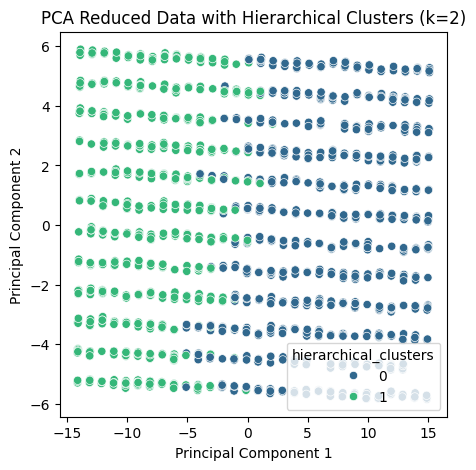

In [76]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_clusters = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
df['hierarchical_clusters'] = hierarchical_clusters.fit_predict(df1)

plt.figure(figsize=(5, 5))
sns.scatterplot(
    x=df1_pca[:, 0],
    y=df1_pca[:, 1],
    hue=df['hierarchical_clusters'],
    palette='viridis',
    legend='full'
)
plt.title('PCA Reduced Data with Hierarchical Clusters (k=2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [77]:
import pickle
model_filename = 'kmeans_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"KMeans model saved to {model_filename}")

KMeans model saved to kmeans_model.pkl


In [78]:
import pickle
import json

# Get the feature columns from the processed DataFrame df1
feature_columns = df1.columns.tolist()

# Define the filename for the feature columns
feature_columns_filename = 'feature_columns.pkl'

# Save the feature columns to a .pkl file
with open(feature_columns_filename, 'wb') as file:
    pickle.dump(feature_columns, file)

print(f"Feature columns saved to {feature_columns_filename}")

# Load the feature columns from the .pkl file (original intent of the cell)
with open(feature_columns_filename, 'rb') as file:
    loaded_feature_columns = pickle.load(file)

print("Loaded feature columns from .pkl file:")
print(loaded_feature_columns)

# If you want to see them in JSON format again:
print("\nLoaded feature columns in JSON format:")
print(json.dumps(loaded_feature_columns, indent=2))

Feature columns saved to feature_columns.pkl
Loaded feature columns from .pkl file:
['Amount', 'Age', 'CourseDuration', 'CourseRating', 'Total_courses_enrolled', 'AvgCoursesPerCategory', 'Enrollment_frequency', 'Year', 'Month', 'Day', 'DayOfWeek', 'AvgCourseRating', 'AvgSpending', 'DiversityScore', 'LevelScore', 'Learningdepthlevel', 'HighlyRated', 'ExcellentCourse', 'LongDurationCourse', 'ShortDurationCourse', 'TotalSpent', 'PaymentMethod_Credit Card', 'PaymentMethod_PayPal', 'Gender_Male', 'Age_group_Young', 'Age_group_Adult', 'Age_group_Senior', 'CourseName_Computer Vision', 'CourseName_Data Encryption', 'CourseName_Deep Learning', 'CourseName_Entrepreneurship 101', 'CourseName_Leadership in Projects', 'CourseName_Project Planning', 'CourseName_Python Basics', 'CourseName_Risk Management', 'CourseName_Statistical Analysis', 'CourseCategory_Business', 'CourseCategory_Cybersecurity', 'CourseCategory_Data Science', 'CourseCategory_Programming', 'CourseCategory_Project Management', 'Cou

In [79]:
import json

columns = {
    'data.columns' : loaded_feature_columns
}

with open('columns.json', 'w') as f:
  f.write(json.dumps(columns, indent=2))